# CIFAR-10 -- Baseline Model & Preprocessing

This first notebook establishes a clean and minimal baseline for CIFAR‑10 image classification using a simple Convolutional Neural Network (CNN).

This notebook intentionally avoids any optimization techniques such as data augmentation, dropout, or advanced architectures.The goal here is not to optimize performance, but to:

- load and inspect the dataset
- build a minimal preprocessing pipeline
- train a simple baseline CNN
- obtain a reference accuracy

This baseline will serve as a starting point for the ablation study in Notebook 2.


## 1 - Librairies :

In [32]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import os

# Ensure reproducibility

SEED=42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

## 2 - Load CIFAR-10 dataset :

In [33]:
(data_train, data_test, data_val), infos = tfds.load(
    'cifar10',
    split=[
        'train[:48000]',              # 80%
        'train[48000:]+test[:4000]',  # 10%
        'test[4000:]'                 # 10%
    ],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

class_names = infos.features['label'].names

print("Dataset loaded successfully.")
print("Train batches:", data_train.cardinality().numpy())
print("Validation batches:", data_val.cardinality().numpy())
print("Test batches:", data_test.cardinality().numpy())

Dataset loaded successfully.
Train batches: 48000
Validation batches: 6000
Test batches: 6000


## 3 - Dataset Overview

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


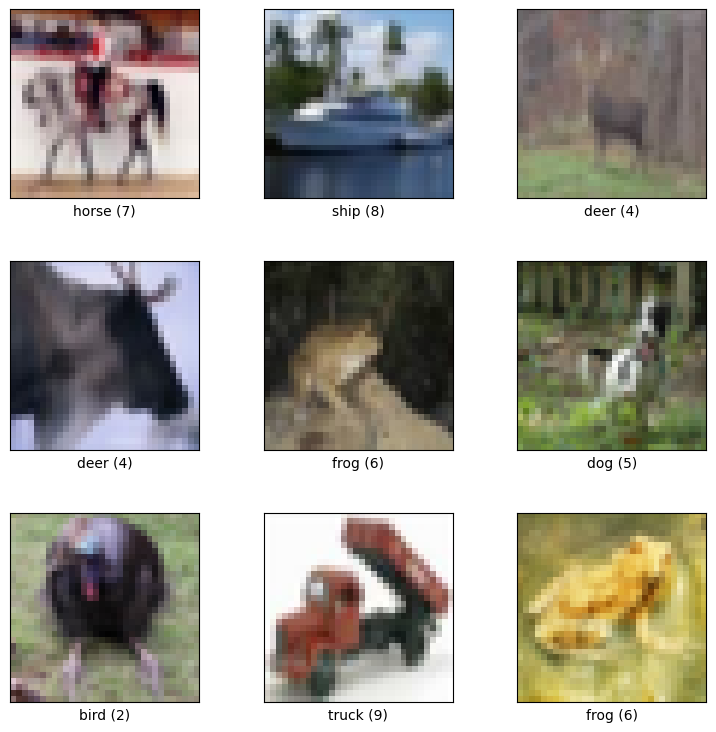

Image dtype: <dtype: 'uint8'>
Min pixel value: 0
Max pixel value: 249


In [34]:
# Extracted class names
print("Classes:", class_names)

# Visualize sample images
tfds.show_examples(data_train,infos);

# Inspect raw pixel values
for image, label in data_train.take(1):
    print("Image dtype:", image.dtype)
    print("Min pixel value:", image.numpy().min())
    print("Max pixel value:", image.numpy().max())

## 4 - Preprocessing Pipeline

To prepare the CIFAR‑10 images for training, we apply a preprocessing pipeline that includes:

- **Resizing** all images to 32×32 (already the native size, but ensures consistency)
- **Rescaling** pixel values to the range [0, 1]
- **Batching** and **prefetching** for efficient GPU utilization

Data augmentation is tested later in notebook 3.

In [35]:
# Preprocessing Layer -> Resize + Rescale
resize_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(32, 32),
    tf.keras.layers.Rescaling(1.0 / 255)
])

# Preprocessing Functions
def preprocess(dataset):

    dataset = dataset.shuffle(buffer_size=1000,seed=SEED)

    # Resize + rescale
    dataset = dataset.map(
        lambda x, y: (resize_rescale(x), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Batch + prefetch
    dataset = dataset.batch(64)
    return dataset.prefetch(tf.data.AUTOTUNE)

In [36]:
# Create Preprocessed Datasets
batch_train = preprocess(data_train)
batch_val   = preprocess(data_val)
batch_test  = preprocess(data_test)

## 5 - Visualizing Preprocessing

Below we compare:
- the original image  
- the resized/rescaled version  

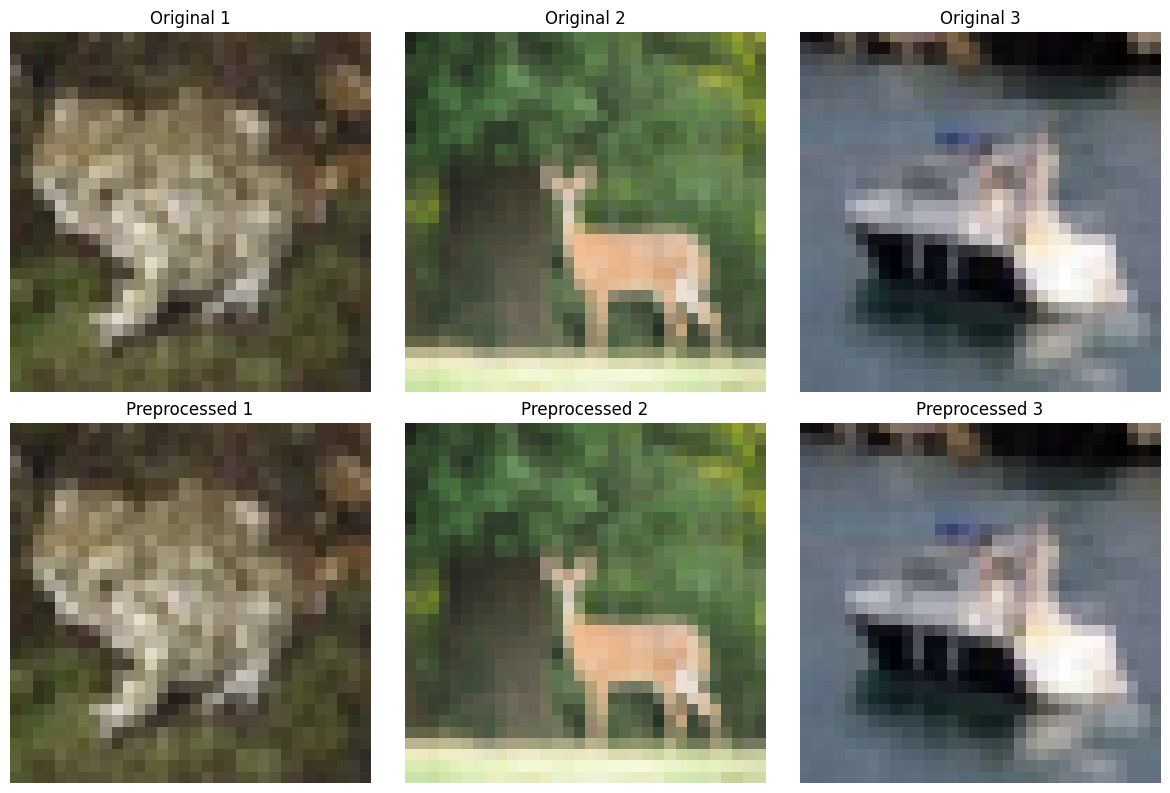

In [37]:
# Take 3 sample images
sample_images = []
for img, label in data_train.shuffle(5000).take(3):
    sample_images.append(img)

plt.figure(figsize=(12, 8))

for i, img in enumerate(sample_images):
    # Original
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Original {i+1}")
    plt.axis("off")

    # Preprocessed
    plt.subplot(2, 3, i + 4)
    plt.imshow(resize_rescale(img))
    plt.title(f"Preprocessed {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 6 - Baseline model :

We start with a simple CNN architecture to establish a baseline performance.  
This model uses:

- Conv(32) -> Batch Normalization -> Conv(32) -> Batch Normalization -> MaxPool -> GlobalAveragePooling -> Dense(10) with softmax activation

This baseline will serve as a reference for all subsequent experiments.

### 6.1 - Define the Model

In [38]:
tf.random.set_seed(SEED)

model_0 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D(),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Activation('softmax', dtype=tf.float32)
])

model_0.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.AdamW(weight_decay=0.004),
    metrics=['accuracy']
)

### 6.2 - Train the Baseline

In [39]:
history_0 = model_0.fit(
    batch_train,
    epochs=10,
    validation_data=batch_val
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.3461 - loss: 1.8276 - val_accuracy: 0.3052 - val_loss: 1.9732
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5103 - loss: 1.4081 - val_accuracy: 0.4438 - val_loss: 1.5345
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5573 - loss: 1.2814 - val_accuracy: 0.5032 - val_loss: 1.3912
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5780 - loss: 1.2155 - val_accuracy: 0.4580 - val_loss: 1.5068
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5928 - loss: 1.1686 - val_accuracy: 0.4997 - val_loss: 1.4753
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6099 - loss: 1.1256 - val_accuracy: 0.5437 - val_loss: 1.2985
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6168 - loss: 1.0989 - val_accuracy: 0.5813 - val_loss: 1.1765
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6277 - loss: 1.0723 - val_accuracy: 

In [40]:
baseline_test_acc = model_0.evaluate(batch_test, verbose=0)[1]
print("Baseline Test Accuracy:", baseline_test_acc)

model_0.summary()

Baseline Test Accuracy: 0.5681666731834412


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,936 (124.75 KB)

 Trainable params: 10,602 (41.41 KB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 21,206 (82.84 KB)

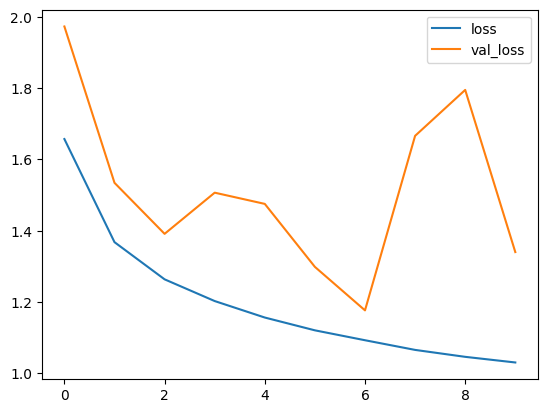

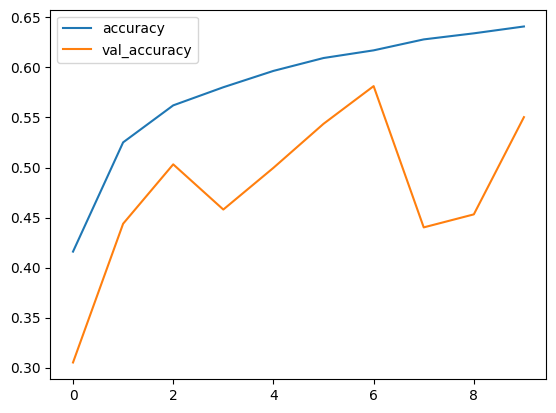

In [41]:
# Accuracy and loss curves
history_df = pd.DataFrame(history_0.history)
history_df.loc[:, ['loss', 'val_loss']].plot()
history_df.loc[:, ['accuracy', 'val_accuracy']].plot()
plt.show()

## 7- Conclusion

## Baseline Summary

In this notebook, we:  
- loaded and inspected the CIFAR‑10 dataset.
- built a clean preprocessing pipeline.
- trained a simple CNN baseline.
- obtained a test accuracy of ≈57%, which is expected for a shallow architecture

This confirms that:  

- the data pipeline works.
- the model trains correctly.
- the baseline provides a solid reference point.

## Next Steps

In **Notebook 2**, we will conduct a systematic **ablation study** to identify:

- the optimal number of convolutional blocks
- the optimal number of filters
- the best regularization strategy
- the best optimizer

The goal is to progressively build a stronger architecture based on empirical evidence.